In [13]:
from matplotlib import pyplot as plt
import pandas as pd

df = pd.read_csv('../data/train_VCN7-T.csv')

serotipos = {
    '1': ('pre PsC SP sp1', 'post PsC SP sp1'),
    '14': ('pre PsC SP sp14', 'post PsC SP sp14'),
    '18C': ('pre PsC SP sp18C', 'post PsC SP sp18C'),
    '19F': ('pre PsC SP sp19F', 'post PsC SP sp19F'),
    '23F': ('pre PsC SP sp23F', 'post PsC SP sp23F'),
    '5': ('pre PsC SP sp5', 'post PsC SP sp5'),
    '6B': ('pre PsC SP sp6B', 'post PsC SP sp6B')
}



In [14]:
df['post PsC SP sp1'] = [value if (float)(value) < 100 else (float)(value)/1000 for value in df['post PsC SP sp1']]
df['post PsC SP sp14'] = [value if (float)(value) < 100 else (float)(value)/1000 for value in df['post PsC SP sp14']]
df['post PsC SP sp18C'] = [value if (float)(value) < 100 else (float)(value)/1000 for value in df['post PsC SP sp18C']]
df['post PsC SP sp19F'] = [value if (float)(value) < 100 else (float)(value)/1000 for value in df['post PsC SP sp19F']]
df['post PsC SP sp23F'] = [value if (float)(value) < 100 else (float)(value)/1000 for value in df['post PsC SP sp23F']]
df['post PsC SP sp5'] = [value if (float)(value) < 100 else (float)(value)/1000 for value in df['post PsC SP sp5']]
df['post PsC SP sp6B'] = [value if (float)(value) < 100 else (float)(value)/1000 for value in df['post PsC SP sp6B']]

df['pre PsC SP sp1'] = [value if (float)(value) < 100 else (float)(value)/1000 for value in df['pre PsC SP sp1']]
df['pre PsC SP sp14'] = [value if (float)(value) < 100 else (float)(value)/1000 for value in df['pre PsC SP sp14']]
df['pre PsC SP sp18C'] = [value if (float)(value) < 100 else (float)(value)/1000 for value in df['pre PsC SP sp18C']]
df['pre PsC SP sp19F'] = [value if (float)(value) < 100 else (float)(value)/1000 for value in df['pre PsC SP sp19F']]
df['pre PsC SP sp23F'] = [value if (float)(value) < 100 else (float)(value)/1000 for value in df['pre PsC SP sp23F']]
df['pre PsC SP sp5'] = [value if (float)(value) < 100 else (float)(value)/1000 for value in df['pre PsC SP sp5']]
df['pre PsC SP sp6B'] = [value if (float)(value) < 100 else (float)(value)/1000 for value in df['pre PsC SP sp6B']]


In [ ]:
import ast

# Leer el contenido del archivo txt
with open('../../log_simulacion.txt', 'r') as f:
    contenido = f.read()
contenido = contenido.replace('np.float64', '')
# Convertir el texto a diccionario
# a = ast.literal_eval(contenido)

SyntaxError: invalid decimal literal (<unknown>, line 2)

In [ ]:
import numpy as np
for m in serotipos.keys():
    plt.scatter(df[f'pre PsC SP sp{m}'], df[f'post PsC SP sp{m}'], color='orange')
    # with open(f'../../log_simulacion{m}.txt', 'r') as f:
    #     contenido = f.read()
    # contenido = contenido.replace('np.float64', '')
    # # Convertir el texto a diccionario
    # a = ast.literal_eval(contenido)
    # for point in a[m]:
    #     plt.scatter(point[0],point[1], color = 'blue')
    plt.title(f'sp{m}')
    plt.xlabel('pre')
    plt.ylabel('pos')
    plt.show()

2.5827500000000003


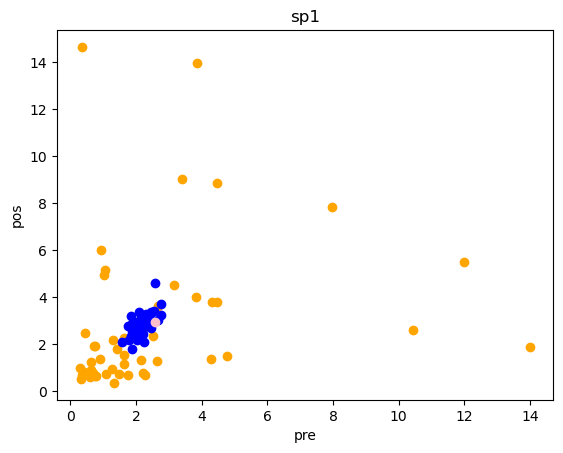

13.201499999999998


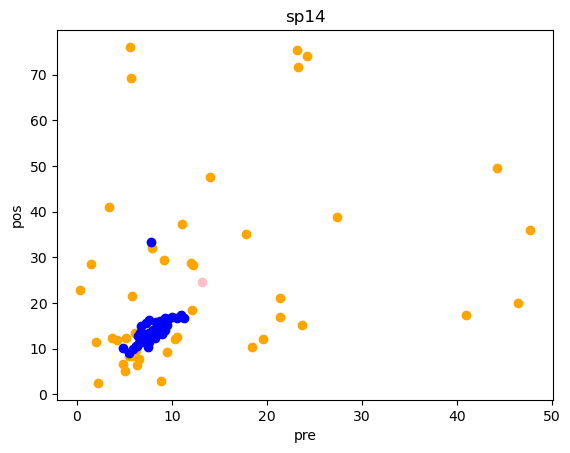

2.115333333333334


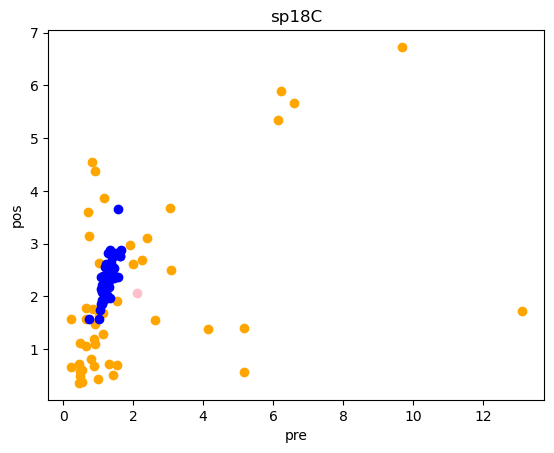

2.7262500000000003


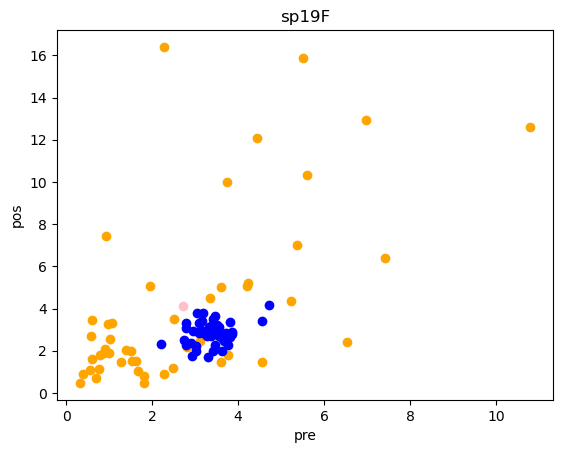

2.367041666666667


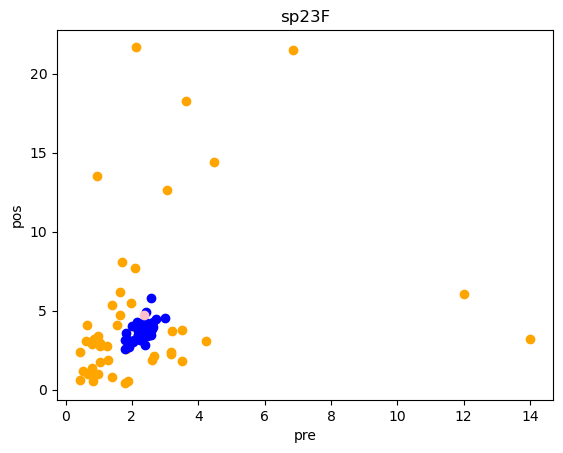

1.0128125


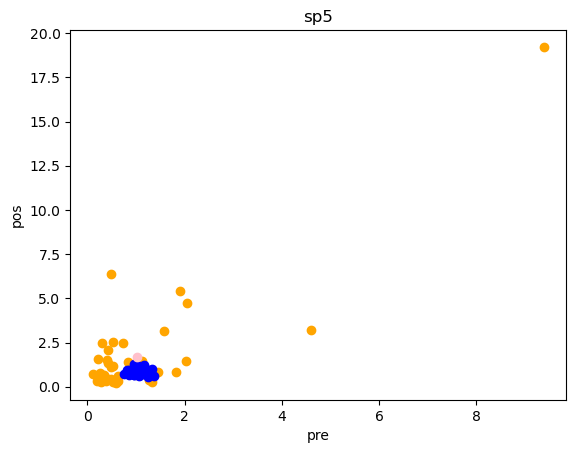

2.5403124999999993


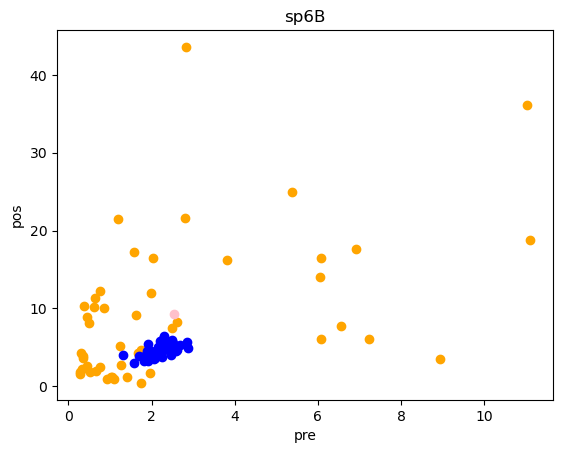

In [15]:
import ast
import numpy as np
for m in serotipos.keys():
    centroide = np.mean(np.array([[df[f'pre PsC SP sp{m}'][i],df[f'post PsC SP sp{m}'][i]]for i in range(len(df[f'pre PsC SP sp{m}']))]), axis=0)
    plt.scatter(df[f'pre PsC SP sp{m}'], df[f'post PsC SP sp{m}'], color='orange')
    with open(f'../../log_simulacion{m}.txt', 'r') as f:
        contenido = f.read()
    contenido = contenido.replace('np.float64', '')
    # Convertir el texto a diccionario
    a = ast.literal_eval(contenido)
    for point in a[m]:
        plt.scatter(point[0],point[1], color = 'blue')
    print(centroide[0])
    plt.scatter(centroide[0], centroide[1], color = 'pink')
    plt.title(f'sp{m}')
    plt.xlabel('pre')
    plt.ylabel('pos')
    plt.show()

In [21]:
df.to_csv('../data/train_VCN7-Tf_fit.csv', index=False)

In [10]:
df = pd.read_csv('../data/test_VCN7-T.csv')

In [8]:
df.to_csv('../data/test_VCN7-Tf_fit.csv', index=False)

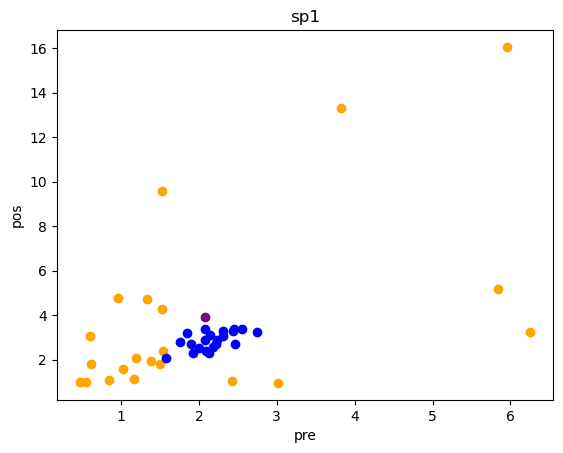

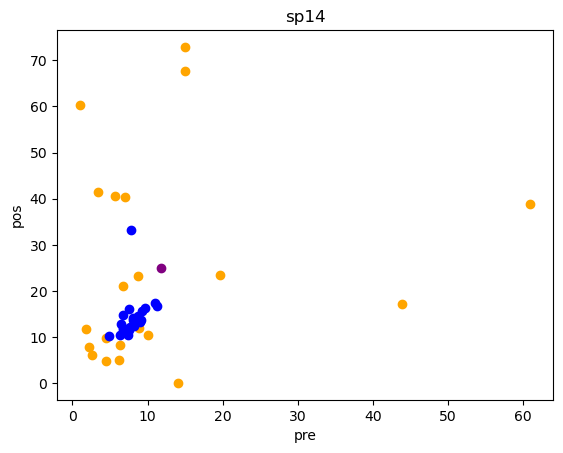

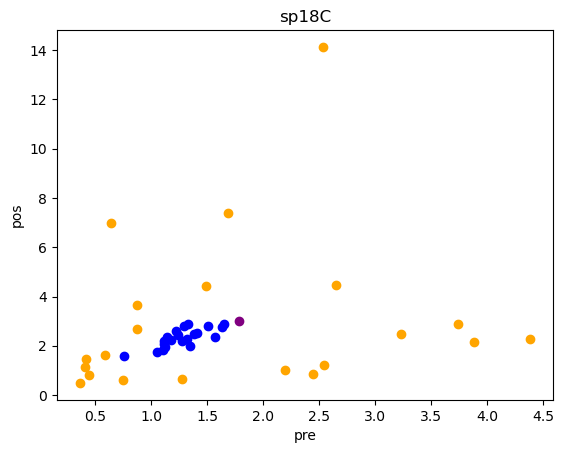

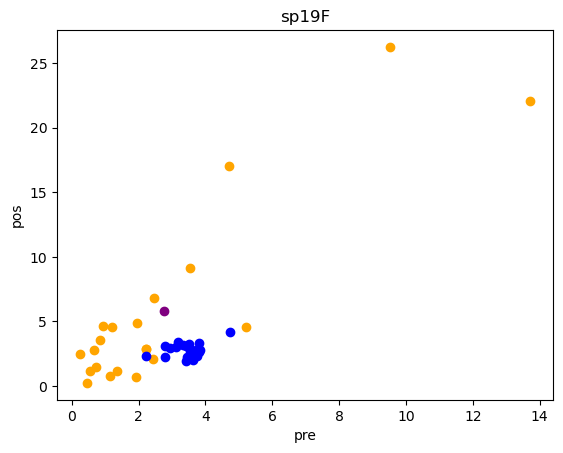

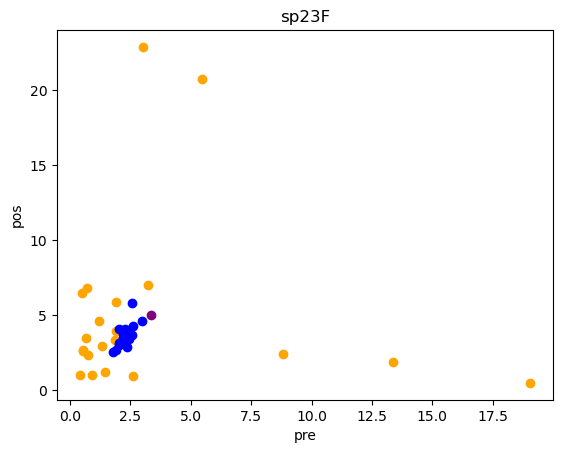

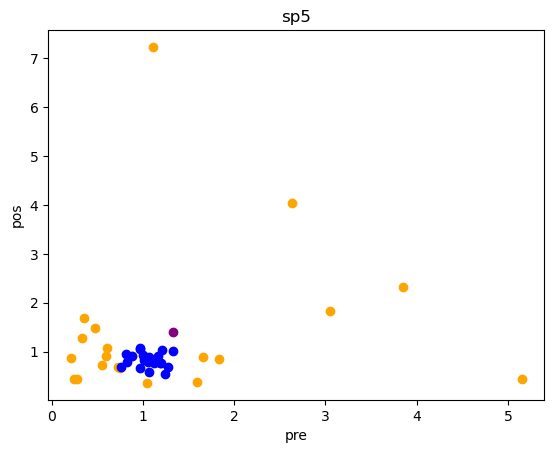

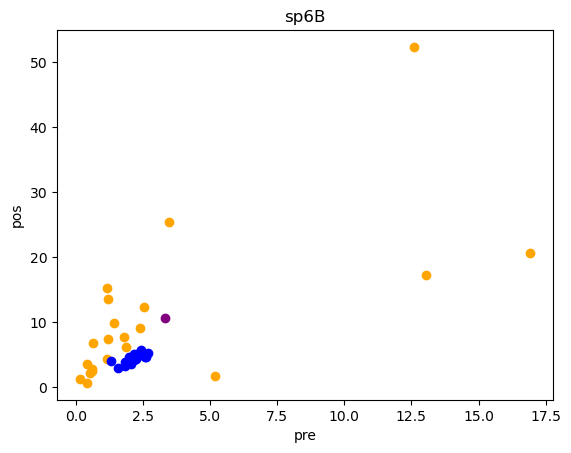

In [12]:
import ast
for m in serotipos.keys():
    centroide = np.mean(np.array([[df[f'pre PsC SP sp{m}'][i],df[f'post PsC SP sp{m}'][i]]for i in range(len(df[f'pre PsC SP sp{m}']))]), axis=0)
    plt.scatter(df[f'pre PsC SP sp{m}'], df[f'post PsC SP sp{m}'], color='orange')
    with open(f'../../log_simulacion{m}.txt', 'r') as f:
        contenido = f.read()
    contenido = contenido.replace('np.float64', '')
    # Convertir el texto a diccionario
    a = ast.literal_eval(contenido)
    for point in a[m][:len(df[f'pre PsC SP sp{m}'])]:
        plt.scatter(point[0],point[1], color = 'blue')
    plt.scatter(centroide[0], centroide[1], color = 'purple')
    plt.title(f'sp{m}')
    plt.xlabel('pre')
    plt.ylabel('pos')
    plt.show()

In [9]:
from scipy.spatial import cKDTree
import numpy as np
def chamfer_distance(points1, points2):
    """
    Calcula la distancia de Chamfer entre dos nubes de puntos 2D.
    points1, points2: arrays numpy de forma (N,2) y (M,2)
    Devuelve un valor escalar que indica la similitud (menor es más parecido).
    """
    # print(np.squeeze(points1).shape)
    points1 = np.squeeze(points1)
    points2 = np.squeeze(points2)

    tree1 = cKDTree(points1)
    tree2 = cKDTree(points2)

    # Para cada punto en points1, distancia al punto más cercano en points2
    dist1, _ = tree2.query(points1)
    # Para cada punto en points2, distancia al punto más cercano en points1
    dist2, _ = tree1.query(points2)

    # Promedio de ambas direcciones
    chamfer_dist = np.mean(dist1) + np.mean(dist2)
    return chamfer_dist

In [19]:

for ser in serotipos.keys():
    pre_vals = df[serotipos[ser][0]].values.reshape(-1, 1)
    post_vals = df[serotipos[ser][1]].values.reshape(-1, 1)
    points1 = [(pre_vals[i], post_vals[i]) for i in range(len(pre_vals))]
    points2 = [(point[0],point[1]) for point in a[m][:len(points1)]]
    
    print(f"Serotipo: {ser}, Métrica: {chamfer_distance(points1, points2)}")

    

Serotipo: 1, Métrica: 3.4222317384409413
Serotipo: 14, Métrica: 26.348060056469624
Serotipo: 18C, Métrica: 2.772776117837329
Serotipo: 19F, Métrica: 4.442466668901309
Serotipo: 23F, Métrica: 4.802988442625531
Serotipo: 5, Métrica: 3.2408041007803448
Serotipo: 6B, Métrica: 8.539118293995685


In [16]:
df2 = pd.read_csv('../data/train_VCN7-Tf_fit.csv')

In [ ]:
for ser in serotipos.keys():
    pre_vals = df2[serotipos[ser][0]].values.reshape(-1, 1)
    post_vals = df2[serotipos[ser][1]].values.reshape(-1, 1)
    points1 = [(pre_vals[i], post_vals[i]) for i in range(len(pre_vals))]
    points2 = [(point[0],point[1]) for point in a[m]]
    
    print(f"Serotipo: {ser}, Métrica: {chamfer_distance(points1, points2)}")

   

Serotipo: 1, Métrica: 3.5266885419495466
Serotipo: 14, Métrica: 25.398556687703163
Serotipo: 18C, Métrica: 3.3204573498169294
Serotipo: 19F, Métrica: 3.25879166776388
Serotipo: 23F, Métrica: 3.283943660996331
Serotipo: 5, Métrica: 2.9536461296227237
Serotipo: 6B, Métrica: 6.594565325909819
